In [1]:
import os

os.environ['KAGGLE_USERNAME'] = 'aishik996'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_61236d6a08ac73ba31896583260ad688'

In [2]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:27<00:00, 41.2MB/s]



In [3]:
import zipfile

with zipfile.ZipFile('dogsvscats.zip','r')as zip_ref:
  zip_ref.extractall('data')

In [63]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout

In [5]:
#generators

train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/data/train',
    labels='inferred',
    image_size=(256,256),
    batch_size=32,
    label_mode='int'
)

validation_ds=keras.utils.image_dataset_from_directory(
    directory='/content/data/test',
    labels='inferred',
    image_size=(256,256),
    batch_size=32,
    label_mode='int'
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [6]:
def process(image,label):
  image=tf.cast(image/255.0,tf.float32)
  return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [7]:
#creating model

model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))



model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,761 (56.64 MB)

 Trainable params: 14,847,761 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [10]:
model.fit(train_ds,epochs=20,validation_data=(validation_ds))

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 77ms/step - accuracy: 0.5818 - loss: 0.6665 - val_accuracy: 0.6790 - val_loss: 0.6047
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.7264 - loss: 0.5354 - val_accuracy: 0.7686 - val_loss: 0.4819
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.8030 - loss: 0.4208 - val_accuracy: 0.7882 - val_loss: 0.4561
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 79ms/step - accuracy: 0.8655 - loss: 0.3070 - val_accuracy: 0.7898 - val_loss: 0.5093
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 84ms/step - accuracy: 0.9236 - loss: 0.1813 - val_accuracy: 0.7866 - val_loss: 0.6806
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9604 - loss: 0.1056 - val_accuracy: 0.7806 - val_loss: 0.8772
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9768 - loss: 0.0674 - val_accuracy: 0.7964 - val_loss: 0.9792
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.9833 - loss: 0.0476 - 

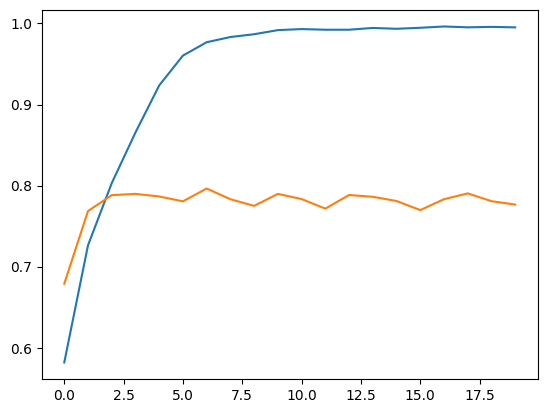

In [11]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['accuracy'],label='accuracy')
plt.plot(model.history.history['val_accuracy'],label='val_accuracy')
plt.show()

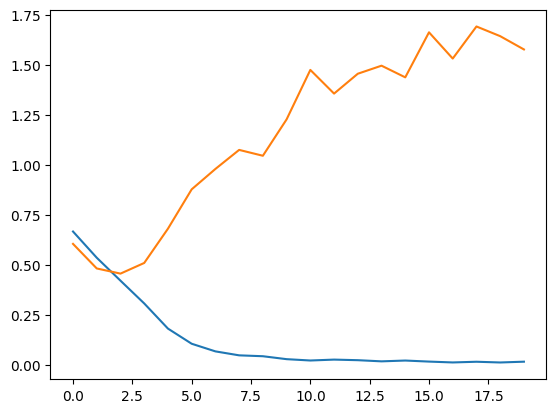

In [12]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'],label='accuracy')
plt.plot(model.history.history['val_loss'],label='val_accuracy')
plt.show()

In [13]:
import pandas as np

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image

In [16]:
img=image.load_img('/content/data/test/cats/cat.10.jpg',target_size=(200,200))

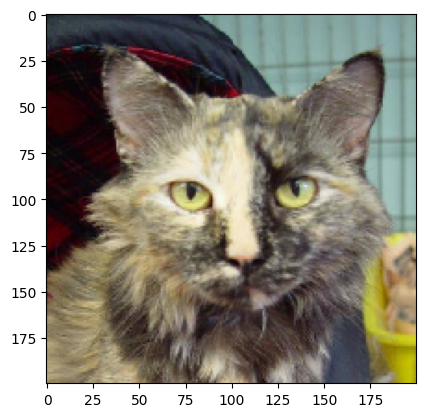

In [17]:
plt.imshow(img)

In [23]:
datagen=ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [25]:
img=image.img_to_array(img)

In [26]:
img.shape

(200, 200, 3)

In [27]:
input_batch=img.reshape(1,200,200,3)

In [28]:
i=0

for output in datagen.flow(input_batch,batch_size=1,save_to_dir='preview',save_prefix='cat',save_format='jpeg'):
  i+=1
  if i>10:
    break

In [39]:
#testing

import cv2

In [41]:
img=cv2.imread('/content/data/catsvsdogs/test/dogs/dog.10006.jpg')

In [42]:
img.shape

(339, 499, 3)

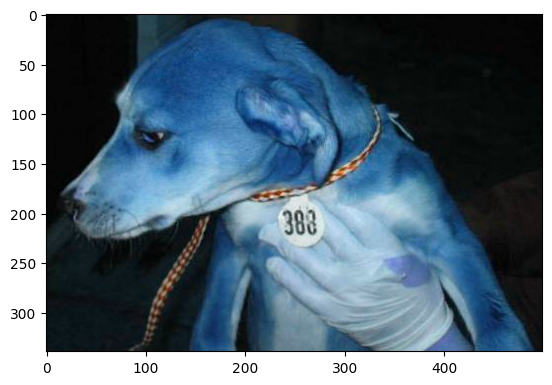

In [43]:
plt.imshow(img)

In [44]:
img=cv2.resize(img,(256,256))

In [45]:
img=img.reshape(1,256,256,3)

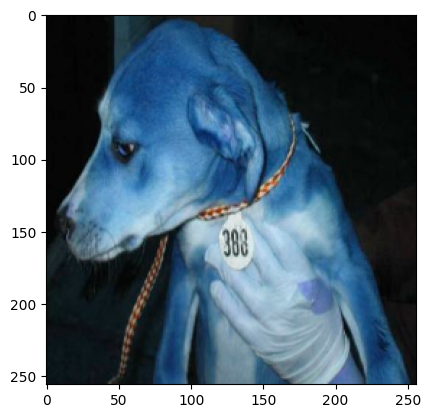

In [47]:
plt.imshow(img[0])

In [48]:
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[1.]], dtype=float32)

In [49]:
#Copy files
import os
import shutil
import random

source_dir = "/content/data/train/dogs"
dest_dir = "/content/train/dogs"

# create destination if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# list all files
files = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]

# randomly select 2000 images
selected_files = random.sample(files, 500)

# copy them
for file in selected_files:
    shutil.copy(os.path.join(source_dir, file),
                os.path.join(dest_dir, file))

print("Done copying 2000 images!")

Done copying 2000 images!


In [50]:
#copy files
import os
import shutil
import random

source_dir = "/content/data/train/cats"
dest_dir = "/content/train/cats"

# create destination if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# list all files
files = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]

# randomly select 2000 images
selected_files = random.sample(files, 500)

# copy them
for file in selected_files:
    shutil.copy(os.path.join(source_dir, file),
                os.path.join(dest_dir, file))

print("Done copying 2000 images!")

Done copying 2000 images!


In [57]:
#Copy files
import os
import shutil
import random

source_dir = "/content/data/test/dogs"
dest_dir = "/content/test/dogs"

# create destination if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# list all files
files = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]

# randomly select 2000 images
selected_files = random.sample(files, 100)

# copy them
for file in selected_files:
    shutil.copy(os.path.join(source_dir, file),
                os.path.join(dest_dir, file))

print("Done copying 100 images!")

Done copying 2000 images!


In [58]:
#Copy files
import os
import shutil
import random

source_dir = "/content/data/test/cats"
dest_dir = "/content/test/cats"

# create destination if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# list all files
files = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]

# randomly select 2000 images
selected_files = random.sample(files, 100)

# copy them
for file in selected_files:
    shutil.copy(os.path.join(source_dir, file),
                os.path.join(dest_dir, file))

print("Done copying 100 images!")

Done copying 100 images!


In [54]:
#augmenting the data

train_datagen=ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

test_datagen=ImageDataGenerator(
    rescale=1./255
)

In [62]:
#creating augmented data

batch_size=16
train_generator=train_datagen.flow_from_directory(
    directory='/content/train',
    target_size=(256,256),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator=test_datagen.flow_from_directory(
    directory='/content/test',
    target_size=(256,256),
    batch_size=batch_size,
    class_mode='binary'
)

Found 1000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [64]:
#creating model

model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))



model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,761 (56.64 MB)

 Trainable params: 14,847,761 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [68]:
model.fit(train_generator, steps_per_epoch=1000//batch_size, epochs=15,validation_data=test_generator)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 354ms/step - accuracy: 0.4888 - loss: 0.8744 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 2/15
 1/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6250 - loss: 0.6880

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6250 - loss: 0.6880 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 283ms/step - accuracy: 0.4817 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5000 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 304ms/step - accuracy: 0.5000 - loss: 0.6926 - val_accuracy: 0.5100 - val_loss: 0.6940
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5000 - loss: 0.6873 - val_accuracy: 0.5100 - val_loss: 0.6940
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.5346 - loss: 0.6902 - val_accuracy: 0.5000 - val_loss: 0.6956
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6250 - loss: 0.6572 - val_accuracy: 0.5100 - val_loss: 0.6954
Epoch 9/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 279ms/step - accuracy: 0.5671 - loss: 0.6795 - val_accuracy: 0.5050 - val_loss

In [ ]:
mode